In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import pandas as pd 
import numpy as np
from tableone import TableOne
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore") 


# Data read-in

In [3]:

DATA_DIR = Path("/Users/mlin2/Desktop/RabLab/tasks/concurrent/data/cleaned_dat")

def exclude_tx(df):
    return df[df.tx_started == 0].drop(
        columns=["tx_start_date", "tx_started"],
        errors="ignore"
    ) 
dat_bl = pd.read_csv(DATA_DIR / "merged_baseline_wDemo.csv")

ptau_final = exclude_tx(pd.read_csv(DATA_DIR / "ptau_cleaned_20260418.csv"))
tau_final  = exclude_tx(pd.read_csv(DATA_DIR / "tau_cleaned_20260418.csv"))
amy_final  = exclude_tx(pd.read_csv(DATA_DIR / "amy_cleaned_20260418.csv"))
cdr_final  = exclude_tx(pd.read_csv(DATA_DIR / "cdr_cleaned_20260418.csv"))
moca_final = exclude_tx(pd.read_csv(DATA_DIR / "moca_cleaned_20260418.csv"))

# Cohort Assignment 

In [4]:
dat_bl = dat_bl.dropna(subset=["ptau217"])#"desikan_suvr",ptau217","centiloid_wcbl"
dat_bl = dat_bl[dat_bl.dx != "CN"]
baseline_subj_list = dat_bl.subject_label.unique()
baseline_eoad_list = dat_bl[dat_bl.dx == "EOAD"].subject_label.unique()
baseline_eononad_list = dat_bl[dat_bl.dx == "EOnonAD"].subject_label.unique()
dat_bl.dx.value_counts()

dx
EOAD       376
EOnonAD    113
Name: count, dtype: int64

# Follow up summary (EOAD)

In [5]:
from utils.longitudinal import summarize_longitudinal

datasets = {
    "ptau217": (ptau_final, "ptau_date"),
    "CDR": (cdr_final, "cdr_date"),
    "Amyloid PET": (amy_final, "amy_date"),
    "Tau PET": (tau_final, "tau_date"),
    "MOCA": (moca_final, "moca_date"),
}

results = {}

for label, (df, date_col) in datasets.items():
    df_filt = df[df.subject_label.isin(baseline_eoad_list)]

    df_long, summary, stats = summarize_longitudinal(df_filt, date_col)

    results[label] = {
        "data": df_long,
        "summary": summary,
        "stats": stats
    }

    print(f"{label}: {stats['n_records']} records from n = {stats['n_subjects']} ({stats['mean_followup']:.1f}±{stats['std_followup']:.1f} yrs)") 

ptau217: 579 records from n = 216 (2.1±1.1 yrs)
CDR: 770 records from n = 262 (2.4±1.3 yrs)
Amyloid PET: 645 records from n = 237 (2.1±0.9 yrs)
Tau PET: 638 records from n = 237 (2.1±1.0 yrs)
MOCA: 666 records from n = 228 (2.4±1.2 yrs)


# Table One (between EOAD and EOnonAD)

In [6]:
# pre-process
dat_bl["apoe4_status"] = dat_bl["apoe4_alleles"].replace({
    0: "Non-Carriers",
    1: "Heterozygous",
    2: "Homozygous"
})
print(dat_bl["apoe4_status"].value_counts())

# config
GROUP_COL = "dx_ptau"

CONT_VARS = [
    "ptau217",
    "centiloid_wcbl",
    "age_at_pet",
    "years_education",
    "mmse_baseline",
    "cdrsb",
    "meta_temporal_suvr",
    "baseline_moca",
   # "mtl_no_hippocampus_FTP_SUVR",
   # "basolateral_temporal_FTP_SUVR",
   # "temporoparietal_FTP_SUVR",
    "desikan_suvr",
   # 'CenTauRz_Universal', 
   # 'CenTauRz_MetaTemporal', 
   # 'CenTauRz_MesialTemporal', 
   # 'CenTauRz_TemporoParietal', 
   # 'CenTauRz_Frontal' 
]

CAT_VARS = [
    "sex",
   # "race",
    "ethnicity",
    "apoe4_status",
    "clinical_severity_baseline",
    "cdr_global",
]

LABELS = {
    "pTau217.Conc..pg.mL.": "Plasma p-tau217 (pg/mL)",
    "Centiloids_wcbl": "[18F]Florbetaben PET Centiloids",
    "age_at_pet": "Age",
    "sex": "Sex",
   # "race": "Race",
    "ethnicity": "Ethnicity",
    "years_education": "Education (years)",
    "apoe4_status": "APOE4 Status",
    "clinical_severity_baseline": "Diagnosis",
    "mmse": "MMSE",
    "cdr_global": "CDR-Global",
    "cdrsb": "CDR-SB",
    "baseline_moca": "MOCA",
    "meta_temporal_suvr": "[18F]Flortaucipir PET SUVR (Meta-temporal)",
   # "mtl_no_hippocampus_FTP_SUVR": "[18F]Flortaucipir PET SUVR (MTL no hippocampus)",
   # "basolateral_temporal_FTP_SUVR": "[18F]Flortaucipir PET SUVR (Basolateral temporal)",
   # "temporoparietal_FTP_SUVR": "[18F]Flortaucipir PET SUVR (Temporoparietal)",
    "desikan_suvr": "[18F]Flortaucipir PET SUVR (Cortical DK)"
}

# input
t1 = dat_bl.copy()

# clean categorical variables
for col in CAT_VARS:
    t1[col] = t1[col].replace(["None", "none", ""], np.nan)
    t1[col] = t1[col].astype("category")

table1 = TableOne(
    data=t1,
    columns=CAT_VARS + CONT_VARS,
    categorical=CAT_VARS,
    groupby=GROUP_COL,
    rename=LABELS,
    pval=True,
    nonnormal=["ptau217"],
    missing=True
)

table1

apoe4_status
Non-Carriers    234
Heterozygous    176
Homozygous       61
Name: count, dtype: int64


Grouped by dx_ptau                                                     
                                                                                     Missing        Overall           EOAD        EOnonAD P-Value
n                                                                                                       489            376            113        
Sex, n (%)                                            Female                                     248 (50.7)     202 (53.7)      46 (40.7)   0.020
                                                      Male                                       241 (49.3)     174 (46.3)      67 (59.3)        
Ethnicity, n (%)                                      Hispanic/Latino                              21 (4.3)       10 (2.7)       11 (9.7)   0.003
                                                      Non-Hispanic/Latino                        468 (95.7)     366 (97.3)     102 (90.3)        
APOE4 Status, n (%)                                   Heterozygous                               176 (36.0)     141 (37.5)      35 (31.0)  <0.001
                                                      Homozygous                                  61 (12.5)      59 (15.7)        2 (1.8)        
                                                      Non-Carriers                               234 (47.9)     161 (42.8)      73 (64.6)        
                                                      None                                         18 (3.7)       15 (4.0)        3 (2.7)        
Diagnosis, n (%)                                      Dementia                                   314 (64.2)     272 (72.3)      42 (37.2)  <0.001
                                                      MCI                                        163 (33.3)      95 (25.3)      68 (60.2)        
                                                      None                                         12 (2.5)        9 (2.4)        3 (2.7)        
CDR-Global, n (%)                                     0.0                                          10 (2.0)        5 (1.3)        5 (4.4)  <0.001
                                                      0.5                                        293 (59.9)     207 (55.1)      86 (76.1)        
                                                      1.0                                        167 (34.2)     149 (39.6)      18 (15.9)        
                                                      2.0                                           1 (0.2)        1 (0.3)        0 (0.0)        
                                                      None                                         18 (3.7)       14 (3.7)        4 (3.5)        
ptau217, median [Q1,Q3]                                                                    0  1.3 [0.7,1.8]  1.5 [1.1,2.0]  0.3 [0.2,0.4]  <0.001
centiloid_wcbl, mean (SD)                                                                  8    79.9 (48.9)   103.2 (27.6)     3.4 (10.0)  <0.001
Age, mean (SD)                                                                            17     59.0 (4.6)     59.2 (4.0)     58.3 (6.3)   0.143
Education (years), mean (SD)                                                               0     15.6 (2.5)     15.6 (2.4)     15.7 (2.7)   0.810
mmse_baseline, mean (SD)                                                                  13     22.4 (5.4)     21.3 (5.4)     26.0 (3.5)  <0.001
CDR-SB, mean (SD)                                                                         18      3.6 (1.9)      3.9 (1.9)      2.6 (1.8)  <0.001
[18F]Flortaucipir PET SUVR (Meta-temporal), mean (SD)                                     17      2.0 (0.6)      2.2 (0.5)      1.2 (0.3)  <0.001
MOCA, mean (SD)                                                                           78     16.7 (6.4)     15.3 (6.2)     21.5 (4.8)  <0.001
[18F]Flortaucipir PET SUVR (Cortical DK), mean (SD)                                       17      1.7 (0.5)      1.9 (0.5)      1.1 

# Distribution of ptau 

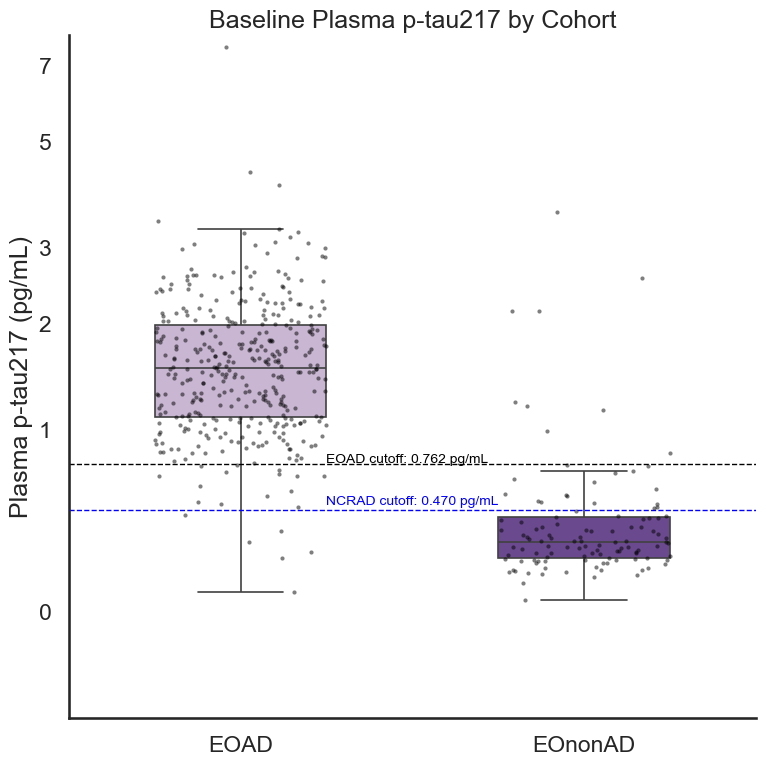

In [7]:
import utils.plotting as plotting

fig, ax = plotting.plot_ptau_box(
    df=dat_bl,
    x_col="dx",
    y_col="ptau217",
    ylabel="Plasma p-tau217 (pg/mL)",
    title="Baseline Plasma p-tau217 by Cohort",
    thresholds=[
        {"value": 0.751, "label": "EOAD cutoff: 0.762 pg/mL", "color": "black"},
        {"value": 0.470, "label": "NCRAD cutoff: 0.470 pg/mL", "color": "blue"},
    ]
)

plt.show()

# Diagnostic performance of p-tau217 in Cognitive Impaired group 

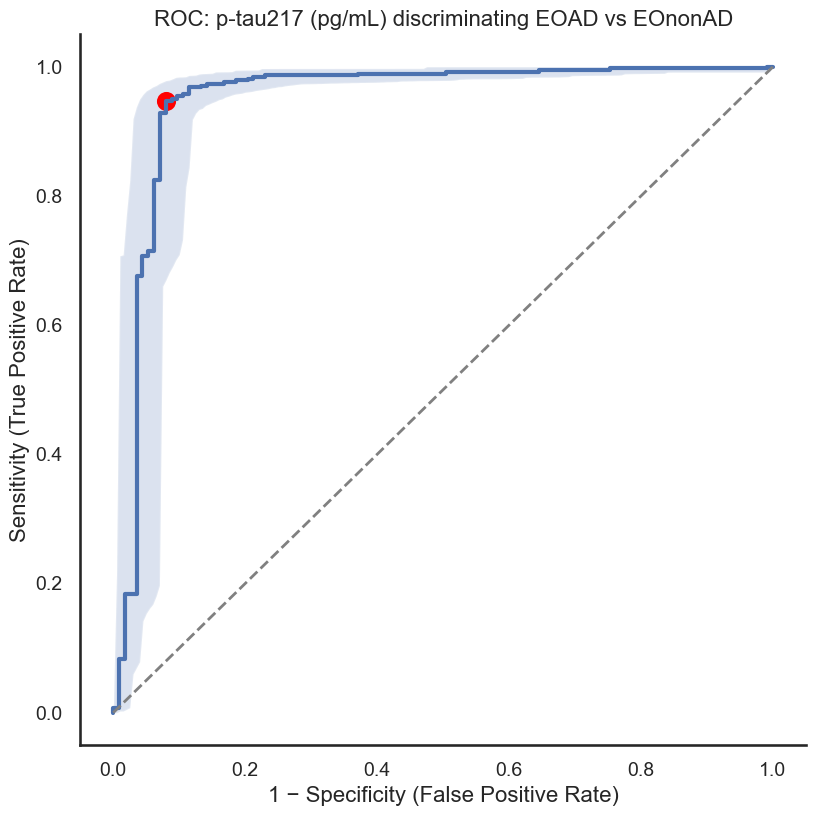

N=489  (EOAD=376, EOnonAD=113)
AUC = 0.948 (DeLong 95% CI 0.907–0.972)
Bootstrap 95% CI 0.915–0.977
Youden cutoff = 0.762


In [8]:
from utils.roc import delong_auc_ci, bootstrap_roc_band
from sklearn.metrics import roc_curve, roc_auc_score 
# config
GROUP_COL = "dx"
POS_LABEL = "EOAD"
NEG_LABEL = "EOnonAD"
PTAU_COL  = "ptau217"

LOG_PTAU = False
BOOTSTRAP_N = 2000
RNG_SEED = 1

if LOG_PTAU:
    dat_bl = dat_bl[dat_bl[PTAU_COL] > 0].copy()
    dat_bl["ptau_used"] = np.log(dat_bl[PTAU_COL].astype(float))
    x_label = "log(p-tau217)"
else:
    dat_bl["ptau_used"] = dat_bl[PTAU_COL].astype(float)
    x_label = "p-tau217 (pg/mL)"

y_true = (dat_bl[GROUP_COL] == POS_LABEL).astype(int).values
y_score = dat_bl["ptau_used"].values

# plot
fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

# Youden index
youden = tpr - fpr
best_idx = int(np.argmax(youden))
best_thr = float(thresholds[best_idx])
#best_sens = float(tpr[best_idx])
#best_spec = float(1 - fpr[best_idx])

# DeLong CI
auc_d, ci_lo, ci_hi = delong_auc_ci(y_true, y_score)

# Bootstrap band
grid_fpr, tpr_lo, tpr_hi, aucb_lo, aucb_hi = bootstrap_roc_band(
    y_true, y_score, n_boot=BOOTSTRAP_N, seed=RNG_SEED
)

# plot
sns.set_theme(style="white", context="talk")

fig, ax = plt.subplots(figsize=(8.5, 8.5))

# Bootstrap ROC band
ax.fill_between(grid_fpr, tpr_lo, tpr_hi, alpha=0.2)

# ROC curve
ax.plot(
    fpr, tpr,
    linewidth=3,
   # label=f"AUC {auc:.2f} ({ci_lo:.2f}–{ci_hi:.2f})"
)

# Chance line
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=2, color="gray")

# Youden point
ax.scatter(
    fpr[best_idx], tpr[best_idx],
    s=150, color="red",
   # label=f"Youden cutoff = {best_thr:.2f}\nSens={best_sens:.2f}, Spec={best_spec:.2f}"
)

# Labels
ax.set_xlabel("1 − Specificity (False Positive Rate)", fontsize=16)
ax.set_ylabel("Sensitivity (True Positive Rate)", fontsize=16)
ax.set_title(f"ROC: {x_label} discriminating {POS_LABEL} vs {NEG_LABEL}", fontsize=16)

ax.tick_params(axis='both', labelsize=14)
#ax.legend(loc="lower right", fontsize=13)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# ----------------------------
# SUMMARY OUTPUT
# ----------------------------
print(f"N={len(dat_bl)}  ({POS_LABEL}={int(y_true.sum())}, {NEG_LABEL}={int((1-y_true).sum())})")
print(f"AUC = {auc:.3f} (DeLong 95% CI {ci_lo:.3f}–{ci_hi:.3f})")
print(f"Bootstrap 95% CI {aucb_lo:.3f}–{aucb_hi:.3f}")
print(f"Youden cutoff = {best_thr:.3f}") 

In [9]:
from utils.roc import compute_threshold_metrics

# threshold
thresholds = {
    "Youden/EOAD": best_thr,
    "NCRAD": 0.470
}
 
thr_results = compute_threshold_metrics(
    y_true,
    y_score,
    thresholds,
    sf=3
)

     Threshold  Cutoff       Sensitivity       Specificity   TP  FP   TN  FN
0  Youden/EOAD   0.762  0.95 (0.92–0.96)  0.92 (0.86–0.96)  356   9  104  20
1        NCRAD   0.470  0.98 (0.97–0.99)  0.78 (0.69–0.84)  370  25   88   6
